# Fall 2025 - Assignment 1
### Students Name and ID:
- Haonan Feng - 11329202
- Navid Namazi Baigi - 11353323

Electronic submission on ZoneCours no later than **October 17 at 11:55 PM** of:

* This Jupyter notebook (.ipynb) as the report, after adding your answers.
* All .py files necessary to run the notebook

The report must:

* be in .ipynb format (points will be deducted for any other format).
* include the student ID number of all team members in the first cell (i.e., replace these instructions).
* answer the questions and discuss the results using tables, figures, and Markdown cells.

Grading rubric:

* **40%** Accuracy of results
* **25%** Complete and concise discussions (Markdown cells)
* **20%** Conciseness of the notebook (.ipynb with minimal code) and clarity of figures
* **15%** Code clarity (.py)

# Context

We are going to consider the most liquid options traded on Apple on two particular business days of 2020: January 17 and March 20. The next couple of code cells were used to generate the dataset by connecting to OptionMetrics. With `GENERATE = False`, they simply load the dataset as saved to disk.

In [1]:
# The following import allow absolute imports scripts within the dorion_francois package
# import internal_script 

import datetime as dt
import os
import sys
import numpy as np
import pandas as pd
import pickle
import importlib
from helpers.data_check import df_summary

# Show all columns, do not truncate horizontally
pd.set_option('display.max_columns', None)
# Show all rows, do not truncate vertically
# pd.set_option('display.max_rows', None)

In [2]:
def filters(options):
    """These filters were applied to the data"""
    # Options before maturity
    options = options.loc[options.date < options.exdate].reset_index()

    # Positive open interest
    options = options[options['open_interest'] > 0] 

    # Abs(delta) between 0.01 and 0.99
    options = options[(options['delta'].abs() >= 0.01) & (options['delta'].abs() <= 0.99)] 

    # Implied vol between 0.03 and 2
    options = options[(options['impl_volatility'] >= 0.03) & (options['impl_volatility'] <= 2)] 

    # Bid price is greater than 0.1 and less than ask price
    options = options[(options['best_offer'] > options['best_bid']) & (options['best_bid'] > 0.1)] 
    
    return options

GENERATE = False
if GENERATE:
    import dorion_francois.option_metrics as om    
    jan17 = om.get_option_data(101594, dt.date(2020,1,17))
    mar20 = om.get_option_data(101594, dt.date(2020,3,20))
    options = filters( pd.concat((jan17,mar20),axis=0) )
    with open('202510-assignment1.pkl','wb') as fh:
        # OptionMetrics 'strike_price' column is the strike x1000. We'll drop it to avoid confusion; use the 'strike' column
        pickle.dump(options.drop(columns=['strike_price']),fh)
else:
    with open('202510-assignment1.pkl','rb') as fh:
        options = pickle.load(fh)

options.reset_index(inplace=True)
display(options.describe())

,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
count,3041.000000,3041.000000,3041.0,3041.0,3041.0,3041.0,3041.0,3041.000000,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3041.0,3.041000e+03,3041.0,3041.0,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3041.000000,3039.000000,2907.000000,3041.000000
mean,2204.334101,1290.575469,101594.0,39.54265,41.070812,302.719171,1493.480434,0.486984,0.051175,0.004216,43.996647,-34.136704,130415376.903321,1.0,0.0,100.0,9.101658e+18,271.62611,40.306731,247.602105,0.678362,0.011057,267.849300,266.408353,268.266957,0.491364,0.463369,0.517211
std,1180.259707,588.418749,0.0,47.505847,48.379765,1413.149222,2810.188475,0.246677,0.573104,0.00421,39.878651,42.649761,3187762.914267,0.0,0.0,0.0,5.314394e+18,89.964556,47.939597,256.838994,0.703668,0.005106,44.329611,44.126488,45.364910,0.240483,0.227888,0.264064
min,28.000000,166.000000,101594.0,0.11,0.14,0.0,1.0,0.209335,-0.989916,0.00004,0.264909,-329.0443,119448757.0,1.0,0.0,100.0,5.077881e+15,75.0,0.13,7.000000,0.019178,0.004597,229.240000,226.093746,227.456884,0.209760,0.004413,0.211192
25%,1205.000000,805.000000,101594.0,3.85,4.75,0.0,76.0,0.308580,-0.332122,0.001665,13.6014,-43.18185,130428991.0,1.0,0.0,100.0,4.510935e+18,205.0,4.25,35.000000,0.095890,0.006167,229.240000,227.603325,228.595023,0.313801,0.290405,0.324194
50%,2273.000000,1334.000000,101594.0,20.05,21.5,14.0,383.0,0.407585,0.02422,0.003027,29.80537,-17.72565,131685030.0,1.0,0.0,100.0,9.095769e+18,270.0,20.8,154.000000,0.421918,0.008564,229.240000,229.240000,229.774853,0.414581,0.389198,0.437239
75%,3271.000000,1800.000000,101594.0,60.75,63.0,97.0,1594.0,0.593389,0.526664,0.005168,64.20898,-9.199282,132338173.0,1.0,0.0,100.0,1.352230e+19,330.0,61.75,455.000000,1.246575,0.016588,318.730000,317.145554,319.221626,0.603811,0.573138,0.637671
max,4085.000000,2345.000000,101594.0,271.0,275.5,29443.0,28015.0,1.998797,0.989859,0.042843,193.543,2.572634,133176505.0,1.0,0.0,100.0,1.844408e+19,520.0,273.25,882.000000,2.416438,0.017424,318.730000,318.730000,325.069560,1.656574,1.601841,2.527934


# Looking At The Data

In [3]:
#split options on Jan 17, 2020 and Mar 20, 2020 into two dataframes
options1=options [options ['date']==dt.date(2020,1,17)].reindex()  #options on Jan 17, 2020
options2=options [options ['date']==dt.date(2020,3,20)].reindex()   #options on Mar 20, 2020
display(options1.head())
display(options2.head())

,level_0,index,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,ss_flag,forward_price,expiry_indicator,root,suffix,hash,strike,option_price,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
0,28,190,101594.0,2020-01-17,AAPL 200124C240000,1,2020-01-24,2020-01-17,C,78.6,79.1,2.0,22.0,0.914445,0.989751,0.00071,1.183559,-26.76116,131551967.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,812455354315213419,240.0,78.85,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.947993,NaN,1.074912
1,64,208,101594.0,2020-01-17,AAPL 200124C285000,1,2020-01-24,2020-01-17,C,33.7,33.9,44.0,2043.0,0.380190,0.985154,0.002416,1.628112,-15.05999,131551985.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,6442975529244062396,285.0,33.8,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.399629,0.332379,0.437975
2,66,209,101594.0,2020-01-17,AAPL 200124C287500,1,2020-01-24,2020-01-17,C,31.2,31.4,89.0,754.0,0.354379,0.984191,0.002736,1.71721,-14.81409,131551986.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,8977840135485698240,287.5,31.3,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.372518,0.308421,0.409034
3,68,210,101594.0,2020-01-17,AAPL 200124C290000,1,2020-01-24,2020-01-17,C,28.75,28.95,318.0,1531.0,0.351879,0.975943,0.003815,2.471972,-21.41726,131551987.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,8524937604001173348,290.0,28.85,True,7,0.019178,0.015771,318.73,318.73,318.675355,0.364211,0.321515,0.394086
4,69,277,101594.0,2020-01-17,AAPL 200124P290000,1,2020-01-24,2020-01-17,P,0.12,0.14,2866.0,9733.0,0.344187,-0.022558,0.003532,2.363225,-21.30008,131552018.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,17541079441124028567,290.0,0.13,False,7,0.019178,0.015771,318.73,318.73,318.675355,0.344050,0.339721,0.348175


,level_0,index,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,ss_flag,forward_price,expiry_indicator,root,suffix,hash,strike,option_price,is_call,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
1312,1908,166,101594.0,2020-03-20,AAPL 200327C135000,1,2020-03-27,2020-03-20,C,93.15,96.4,1.0,56.0,1.998797,0.979937,0.000766,1.543098,-81.38992,132995045.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,2351176369942867699,135.0,94.775,True,7,0.019178,0.00745,229.24,229.24,229.699957,1.565938,NaN,2.527934
1313,1910,167,101594.0,2020-03-20,AAPL 200327C140000,1,2020-03-27,2020-03-13,C,88.25,91.05,0.0,11.0,1.793695,0.982596,0.000756,1.364458,-64.95656,132737814.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,6570680480884333529,140.0,89.65,True,7,0.019178,0.00745,229.24,229.24,229.699957,NaN,NaN,2.265144
1314,1911,247,101594.0,2020-03-20,AAPL 200327P140000,1,2020-03-27,2020-03-20,P,0.17,0.28,506.0,1312.0,1.651492,-0.011545,0.000577,0.960129,-41.32759,132737826.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,11812381253929513101,140.0,0.225,False,7,0.019178,0.00745,229.24,229.24,229.699957,1.656574,1.593775,1.709908
1315,1912,168,101594.0,2020-03-20,AAPL 200327C145000,1,2020-03-27,2020-03-17,C,83.3,86.05,0.0,38.0,1.697518,0.980642,0.000875,1.494512,-67.3017,132737815.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,15269956671680196482,145.0,84.675,True,7,0.019178,0.00745,229.24,229.24,229.699957,NaN,NaN,2.129291
1316,1913,248,101594.0,2020-03-20,AAPL 200327P145000,1,2020-03-27,2020-03-20,P,0.28,0.32,304.0,288.0,1.613269,-0.015266,0.000752,1.222757,-51.37753,132737827.0,1.0,0.0,100.0,0,<NA>,w,<NA>,<NA>,10699880681992102797,145.0,0.3,False,7,0.019178,0.00745,229.24,229.24,229.699957,1.618606,1.601841,1.634672


In [4]:
#summary reports of options1 and options2
num_report1, non_num_report1 = df_summary(options1)
num_report2, non_num_report2 = df_summary(options2)
print("options on 2020,1,17 - Numerical columns Summary")
display(num_report1)
print("options on 2020,1,17 - Non-Numerical columns Summary")
display(non_num_report1)
print("options on 2020,3,20 - Numerical columns Summary")
display(num_report2)
print("options on 2020,3,20 - Non-Numerical columns Summary")
display(non_num_report2)

options on 2020,1,17 - Numerical columns Summary


,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
nan_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40,0
unique_count,1312,1312,1,896,904,382,901,1306,1312,1217,1312,1312,1312,1,1,1,1312,96,1110,16,16,16,1,9,16,1311,1272,1312
zero_count,0,0,0,0,0,320,0,0,0,0,0,0,0,0,1312,0,0,0,0,0,0,0,0,0,0,0,0,0
negative_count,0,0,0,0,0,0,0,0,614,0,0,1307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
min,28.0,190.0,101594.0,0.11,0.14,0.0,1.0,0.209335,-0.98457,0.000171,1.183559,-111.796,119448772.0,1.0,0.0,100.0,13250388696589696.0,110.0,0.13,7.0,0.019178,0.015771,318.73,314.852783,318.397407,0.20976,0.184678,0.211192
max,1902.0,2073.0,101594.0,197.15,201.25,29443.0,28015.0,0.914445,0.989859,0.042843,193.543,1.297433,132032992.0,1.0,0.0,100.0,18437254655043551232.0,520.0,199.175,882.0,2.416438,0.017424,318.73,318.73,325.06956,0.947993,0.541932,1.074912
mean,1027.757622,1197.373476,101594.0,33.962896,34.953216,392.5,1725.449695,0.311605,0.166316,0.005123,47.968484,-22.485545,130214527.278963,1.0,0.0,100.0,9301588776903690240.0,293.155488,34.458056,255.697409,0.700541,0.016753,318.73,317.039651,320.308706,0.317361,0.299826,0.330087
std,546.772013,548.487323,0.0,43.700025,44.531697,1860.557675,3128.533185,0.064687,0.560041,0.00567,47.316863,22.423878,2929377.294483,0.0,0.0,0.0,5372491535389096960.0,80.471052,44.113408,271.535115,0.743932,0.000495,0.0,1.204996,2.055714,0.070283,0.059376,0.080376
dtype,int64,int64,Float64,Float64,Float64,Float64,Float64,float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,uint64,Float64,Float64,int64,float64,float64,float64,float64,float64,float64,float64,float64


options on 2020,1,17 - Non-Numerical columns Summary


,date,symbol,symbol_flag,exdate,last_date,cp_flag,ss_flag,forward_price,expiry_indicator,root,suffix,is_call
nan_count,0,0,0,0,0,0,0,1312,914,1312,1312,0
unique_count,1,1312,1,16,31,2,1,0,1,0,0,2
empty_str_count,0,0,0,0,0,0,0,0,0,0,0,0
dtype,object,string[python],string[python],object,string[python],string[python],string[python],string[python],string[python],string[python],string[python],boolean
most_freq,2020-01-17,AAPL 200124C240000,1,2022-01-21,2020-01-17,C,0,None,w,None,None,True
most_freq_count,1312,1,1312,108,992,698,1312,0,398,0,0,698


options on 2020,3,20 - Numerical columns Summary


,level_0,index,secid,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,cfadj,am_settlement,contract_size,hash,strike,option_price,DTM,YTM,risk_free,stock_price,stock_exdiv,implied_forward_price,implied_vol_bms,implied_vol_bid,implied_vol_ask
nan_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,94,0
unique_count,1729,1729,1,1163,1221,418,1008,1726,1727,1523,1729,1729,1729,1,1,1,1729,106,1479,17,17,17,1,8,17,1723,1635,1729
zero_count,0,0,0,0,0,453,0,0,0,0,0,0,0,0,1729,0,0,0,0,0,0,0,0,0,0,0,0,0
negative_count,0,0,0,0,0,0,0,0,864,0,0,1711,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
min,1908.0,166.0,101594.0,0.12,0.18,0.0,1.0,0.232589,-0.989916,0.00004,0.264909,-329.0443,119448757.0,1.0,0.0,100.0,5077881350980829.0,75.0,0.16,7.0,0.019178,0.004597,229.24,226.093746,227.456884,0.341526,0.004413,0.367105
max,4085.0,2345.0,101594.0,271.0,275.5,16757.0,23485.0,1.998797,0.982596,0.013658,133.6303,2.572634,133176505.0,1.0,0.0,100.0,18444084649137674240.0,520.0,273.25,819.0,2.243836,0.008636,229.24,229.24,229.774931,1.656574,1.601841,2.527934
mean,3097.144014,1361.299017,101594.0,43.77668,45.712967,234.591671,1317.45749,0.620065,-0.036197,0.003528,40.982737,-42.977838,130567785.640833,1.0,0.0,100.0,8949946131303458816.0,255.289184,44.744824,241.459225,0.661532,0.006735,229.24,227.988305,228.776631,0.623555,0.590602,0.659205
std,612.550597,607.683865,0.0,49.798432,50.628347,936.031457,2528.940538,0.250602,0.567594,0.002387,32.834379,51.354929,3363480.100924,0.0,0.0,0.0,5266373584316467200.0,93.310755,50.210273,245.001504,0.671237,0.001531,0.0,1.047725,0.763007,0.239878,0.229345,0.26648
dtype,int64,int64,Float64,Float64,Float64,Float64,Float64,float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,uint64,Float64,Float64,int64,float64,float64,float64,float64,float64,float64,float64,float64


options on 2020,3,20 - Non-Numerical columns Summary


,date,symbol,symbol_flag,exdate,last_date,cp_flag,ss_flag,forward_price,expiry_indicator,root,suffix,is_call
nan_count,0,0,0,0,0,0,0,1729,1272,1729,1729,0
unique_count,1,1729,1,17,35,2,1,0,1,0,0,2
empty_str_count,0,0,0,0,0,0,0,0,0,0,0,0
dtype,object,string[python],string[python],object,string[python],string[python],string[python],string[python],string[python],string[python],string[python],boolean
most_freq,2020-03-20,AAPL 200327C135000,1,2021-01-15,2020-03-20,C,0,None,w,None,None,True
most_freq_count,1729,1,1729,130,1276,865,1729,0,457,0,0,865


# Question 1

Create a scatter plot with the risk-free rate (`100*options.risk_free`) against the time to maturity expressed in years (`options.YTM`). Discuss the figure. Given that the Black-Merton-Scholes economy assumes that the risk-free rate is constant, should one still account for the variation it illustrates if pricing options with the model? Why?

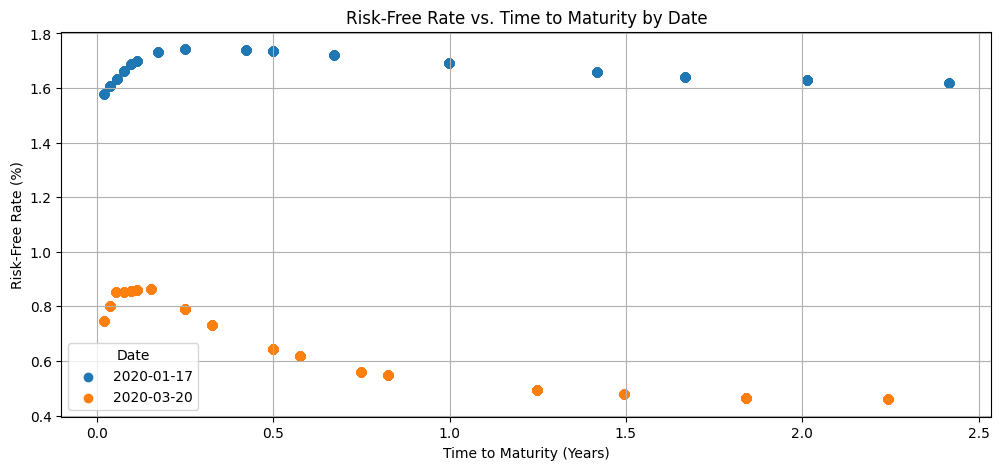

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))
plt.scatter(options1['YTM'], 100 * options1['risk_free'], color='tab:blue', label='2020-01-17')
plt.scatter(options2['YTM'], 100 * options2['risk_free'], color='tab:orange', label='2020-03-20')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Risk-Free Rate (%)')
plt.title('Risk-Free Rate vs. Time to Maturity by Date')
plt.legend(title='Date')
plt.grid(True)
plt.show()

**Discussion:**


- The scatter plot shows how the risk-free rate (annualized, in %) varies with the time to maturity for Apple options on two dates.
- Large differences between the two dates (blue and orange dots) reflect changes in monetary policy and market conditions, especially emergency rate cuts due to the COVID-19 pandemic on March 3 and March 15, 2020.
- If the risk-free rate were truly constant (as assumed in Black-Scholes), all blue and orange points whith same time to maturity would have the same rate.
- The variation within each day based on time to maturity reflects the term structure of interest rates at that date (i.e., the yield curve).

<hr style="border: none; border-top: 1px dashed gray;">

**BMS assumes r is constant through time for a given option, not necessarily the same for all options. So, to reflect the yield curve for each option, we can use the risk-free rate corresponding to its own maturity.**

To account for changes in r through time, if we treat r as stochastic, the BSM closed-form solution cannot be used. If we assume r is a deterministic function of time, the BSM formula can be modified as shown below, and the closed-form solution still exists.
$$
C = S_0 \, N(d_1) - K \, e^{-rT} N(d_2)
$$

where

$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

If r = r(t) is a deterministic function of time, the modified formula is:

$$
C = S_0 \, N(d_1) - K \, e^{-\int_0^T r(t)\,dt} N(d_2)
$$

where

$$
d_1 = \frac{\ln(S_0/K) + \left( \int_0^T r(t) dt + \frac{1}{2}\sigma^2 T \right)}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

***

# Question 2
Similarly, scatter `options.stock - options.stock_exdiv`, where the former is the stock price and the latter accounts for the dividends **actually** paid over the life of the options.

Discuss the figure. Can we conclude that Apple changed its dividend policy between the two dates? Describe which variation of the Black-Merton-Scholes formula seen in class could be used to price the options on Apple if they were European options. Support your discussion with succinct mathematical expressions and/or derivations, in which you can focus on the calls without loss of generality.

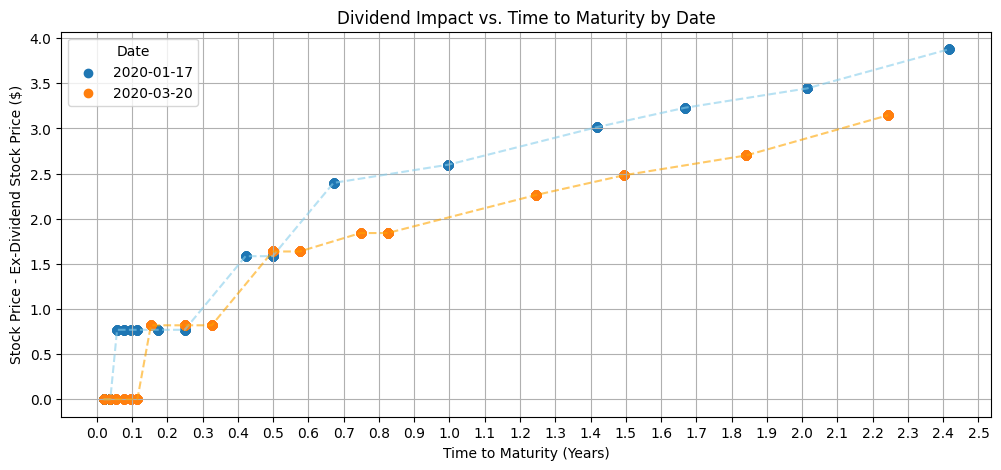

In [6]:
plt.figure(figsize=(12, 5))
plt.xticks(np.arange(0, max(options1['YTM'].max(), options2['YTM'].max()) + 0.1, 0.1))
plt.scatter(options1['YTM'], options1['stock_price'] - options1['stock_exdiv'], color='tab:blue', label='2020-01-17')
plt.scatter(options2['YTM'], options2['stock_price'] - options2['stock_exdiv'], color='tab:orange', label='2020-03-20')
plt.plot(options1['YTM'],options1['stock_price'] - options1['stock_exdiv'],color='skyblue',linestyle='--',alpha=0.6)
plt.plot(options2['YTM'],options2['stock_price'] - options2['stock_exdiv'],color='orange',linestyle='--',alpha=0.6)
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Stock Price - Ex-Dividend Stock Price ($)')
plt.title('Dividend Impact vs. Time to Maturity by Date')
plt.legend(title='Date')
plt.grid(True)
plt.show()

**Discussion:**
- **No! We can not conclude that Apple changed its dividend policy between the two dates**
- Both dates display increasing values as maturity extends, which is reasonable since longer-dated options accrue the present value of more future dividends.
- The vertical difference between the blue and orange dots at the same maturity does not by itself indicate a change in dividend policy, because a blue and an orange dot at the same T represent options initiated two months apart and their life spans may capture a different range of dividend payments. For example, around T=0.1, orange dots are at y=0 while blue dots are at y≈0.75. This is not because Apple changed its dividends, but rather that the options with small T on January 17 could include a soon-to-be-paid dividend (which was actually paid on march), while those on March 20 may not.
- The similarity in slope and shape of the blue and orange curves strongly suggests the underlying dividend policy was stable between the two dates. If there were a meaningful change in policy,we would expect a separation or a shift in curve shape—this is not observed here.
- finally, since as the question mentions these are based on actual dividents (not expected or announced dividents at 2020-01-17 for blue options and at 2020-03-20 for orange ones), then even if the policy would have been changed between these two dates, it would not be observable in our data. so the question is not reasonable!
also if you search for apples change of dividend announcement there has been not in this period

<hr style="border: none; border-top: 1px dashed gray;">


For European call options on a stock paying discrete dividends, the BMS formula adjusts for dividends as follows:

$$
c(t, T, K) = e^{-r(T-t)} \left[ F(t, T)\,\mathcal{N}(d_1) - K\,\mathcal{N}(d_2) \right]
$$

where

$$
d_1 = \frac{\ln \left( \frac{F(t,T)}{K} \right) + \frac{\sigma^2}{2}(T-t)}{\sigma \sqrt{T-t}}, \quad
d_2 = d_1 - \sigma \sqrt{T-t}
$$

and

$$
F(t, T) = e^{r(T-t)} \left( S(t) - \sum_{n=1}^N d(t_n) e^{-r(t_n-t)} \right ) = e^{r(T-t)} (S(t) - I(t, T))
$$

with $S(t)$ the spot price, $d(t_n)$ the dividend paid at time $t_n$, $I(t, T)$ the sum of present values of all dividends before maturity, $N$ the number of dividends before expiry, $r$ the risk-free rate, $\sigma$ the volatility.

This formula prices the call using the stock price minus the present value of all expected dividends before maturity, assuming each dividend triggers an instantaneous price drop equal to the dividend amount.


### <span style="color: red;">the prof used cash and carry for this??? what does the question mean by "Support your discussion with succinct mathematical expressions and/or derivations, in which you can focus on the calls without loss of generality." ????</span>
***

# Question 3
Implement a function that inverts this variation of the BSM formula to obtain the BMS implied volatility for each of the options in the dataframe. Define moneyness as $M = K / \hat{S}_t$ and focus on out-of-the-money (OTM) options ($M \le 1$ puts, $M > 1$ calls). Create a dataframe `otm_options` containing only those options and add a column with the result of your IV calculation for each option therein.

In a 1x2 figure, scatter your results, with  on the x-axis, against a line plot for `implied_vol_bms`: In the left (right) panel, use options quoted on Jan 17 and expiring on Feb 14 (July 17), 2020, and options quoted on Mar 20 expiring on April 17 (Oct. 16), 2020. On each panel, you should thus have 2 lines with your results scattered atop them. Discuss this figure: how does the level and span (across moneyness) of the smiles vary, compare across maturities, etc. Given your discussion, can you suggest a better measure for moneyness? If you generate anew the previous figure using this alternate moneyness measure, how does it impact your analysis of the figure?

In [7]:
from helpers.BMS_IV import implied_vol_BMS

# filtering for Out-of-the-money options
options['moneyness'] = options['strike'] / options['stock_exdiv']
otm_options_call = options[(options['moneyness'] > 1) & (options['cp_flag'] == 'C')]
otm_options_put = options[(options['moneyness'] <= 1) & (options['cp_flag'] == 'P')]
otm_options = pd.concat((otm_options_call, otm_options_put), axis=0)

# Calculate the implied vol for Out-of-the-money options 
otm_options['self_calc_imp_vol_BMS'] = otm_options.apply(
    lambda row: implied_vol_BMS(row['cp_flag'], row['stock_exdiv'], row['strike'], row['risk_free'], row['YTM'], row['option_price'],"brentq"),
    axis = 1
)

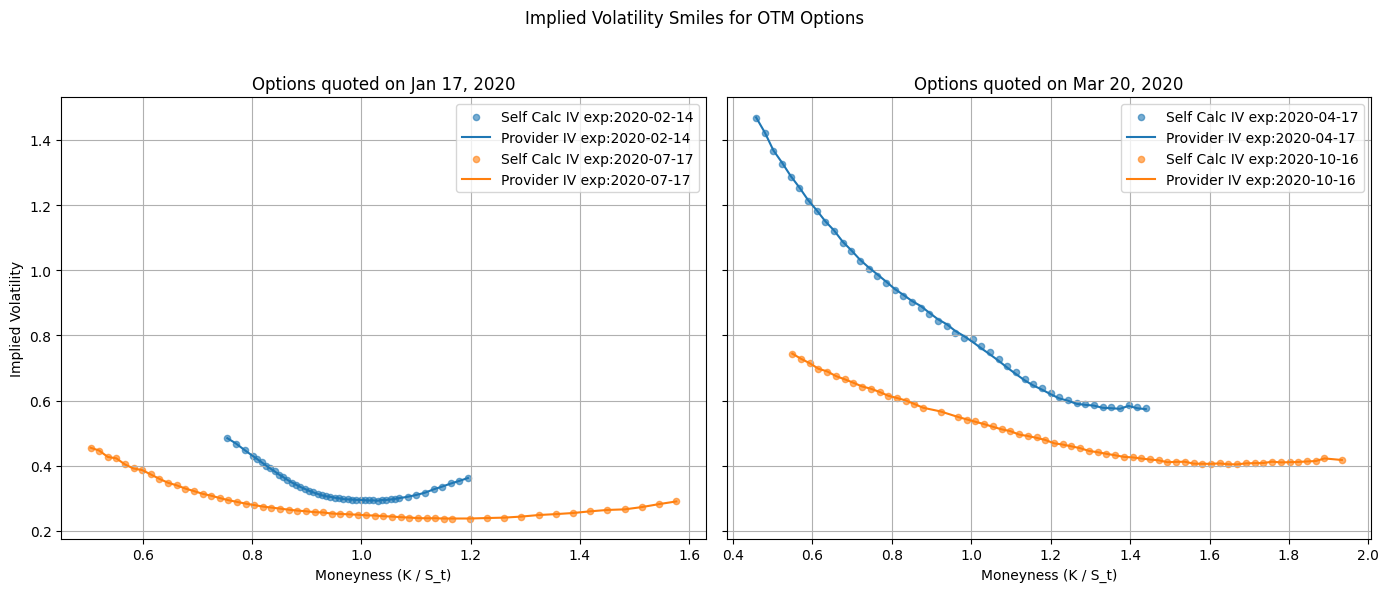

In [8]:
import matplotlib.pyplot as plt
import datetime as dt

options_jan17 = otm_options[otm_options['date'] == dt.date(2020,1,17)]
options_mar20 = otm_options[otm_options['date'] == dt.date(2020,3,20)]

maturities_jan17 = [dt.date(2020,2,14), dt.date(2020,7,17)]
maturities_mar20 = [dt.date(2020,4,17), dt.date(2020,10,16)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left panel: Jan 17 options
ax = axes[0]
for exdate in maturities_jan17:
    df = options_jan17[options_jan17['exdate'] == exdate]
    ax.scatter(df['moneyness'], df['self_calc_imp_vol_BMS'], s=20, alpha=0.6, label=f'Self Calc IV exp:{exdate}')
    df_sorted = df.sort_values('moneyness')
    ax.plot(df_sorted['moneyness'], df_sorted['implied_vol_bms'], label=f'Provider IV exp:{exdate}')
ax.set_title('Options quoted on Jan 17, 2020')
ax.set_xlabel('Moneyness (K / S_t)')
ax.set_ylabel('Implied Volatility')
ax.grid(True)
ax.legend()

# Right panel: Mar 20 options
ax = axes[1]
for exdate in maturities_mar20:
    df = options_mar20[options_mar20['exdate'] == exdate]
    ax.scatter(df['moneyness'], df['self_calc_imp_vol_BMS'], s=20, alpha=0.6, label=f'Self Calc IV exp:{exdate}')
    df_sorted = df.sort_values('moneyness')
    ax.plot(df_sorted['moneyness'], df_sorted['implied_vol_bms'], label=f'Provider IV exp:{exdate}')
ax.set_title('Options quoted on Mar 20, 2020')
ax.set_xlabel('Moneyness (K / S_t)')
ax.grid(True)
ax.legend()

plt.suptitle('Implied Volatility Smiles for OTM Options')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Discussion:**

The graphs above compare our **self-calculated implied volatilities** (in blue) obtained by inverting the **BMS** formula, with the **market-provided implied volatilities** (in orange) for out-of-the-money Apple options on two trading dates.

In both periods, the blue lines lie systematically above the orange lines.  

This occurs because our computation treats **American options as if they were European**, while the market quotes reflect the true **American-style prices**.  
For a given set of parameters $ (S_t, K, r, q, \sigma, T) $, an American option always satisfies  

$$
C_{\text{American}} \geq C_{\text{European}},
$$

due to the **early-exercise premium**.

When we invert the European BSM model to recover implied volatility from the higher American price, the model must compensate by producing a higher volatility estimate:

$$
\sigma_{\text{implied, BSM, European assumption}} \;>\;
\sigma_{\text{market, American pricing}}
$$

Hence, the upward shift of the self-calculated curve relative to the provider curve reflects the **early-exercise feature**.

Moreover, both dates display the expected **volatility smile / skew** shape — implied volatility increases for deep OTM puts (high $K/S_t$ )and sometimes for deep ITM calls (low $K/S_t$).  
Between January and March 2020, the overall level of implied volatility also rose sharply, consistent with the **market varies during the early COVID-19 period**.


# Question 4

Consider the same OTM options as in the previous question. We now want to scatter
\begin{equation}
    100 \left(\frac{ \text{'impl\_volatility'} }{ \text{'implied\_vol\_bms'} } - 1\right)
\end{equation}
against moneyness (the version you feel most comfortable with). The 'impl_volatility' column provides an implied volatility measure as computed by the data provider using a proprietary algorithm. How should the y-axis be interpreted? Are the magnitudes relatively large or small? Would we obtain the same result comparing CRR and BMS implied volatilities for the in-the-money (ITM) options?

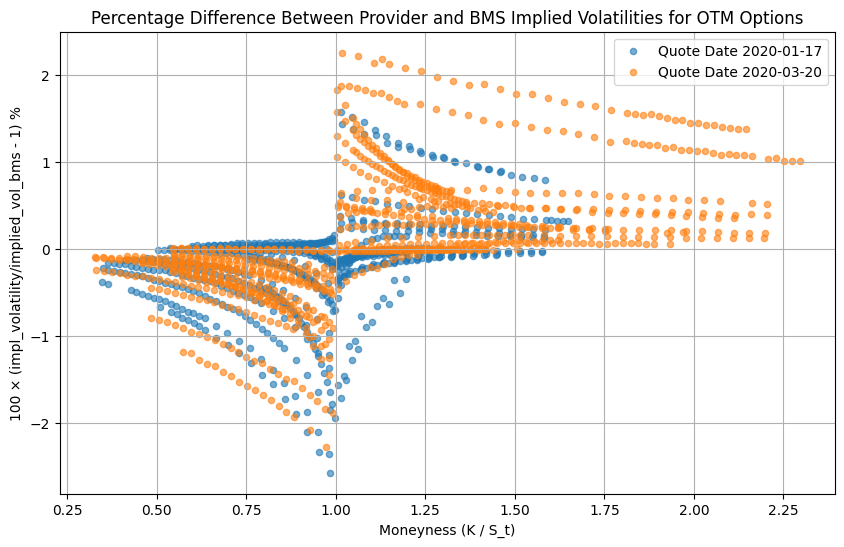

In [9]:
import matplotlib.pyplot as plt
import datetime as dt

# Filter options by quote date
options_jan17 = otm_options[otm_options['date'] == dt.date(2020, 1, 17)]
options_mar20 = otm_options[otm_options['date'] == dt.date(2020, 3, 20)]

plt.figure(figsize=(10, 6))

plt.scatter(options_jan17['moneyness'], 
            100 * (options_jan17['impl_volatility'] / options_jan17['implied_vol_bms'] - 1),
            alpha=0.6, s=20, label='Quote Date 2020-01-17')

plt.scatter(options_mar20['moneyness'], 
            100 * (options_mar20['impl_volatility'] / options_mar20['implied_vol_bms'] - 1),
            alpha=0.6, s=20, label='Quote Date 2020-03-20')

plt.xlabel('Moneyness (K / S_t)')
plt.ylabel('100 × (impl_volatility/implied_vol_bms - 1) %')
plt.title('Percentage Difference Between Provider and BMS Implied Volatilities for OTM Options')
plt.grid(True)
plt.legend()
plt.show()


### **Discussion**

The scatter plot shows the percentage difference  
$$
 100 \times \left(\frac{\text{impl\_volatility}}{\text{implied\_vol\_bms}} - 1\right)
$$ 
between the implied volatilities obtained from the **CRR binomial tree** (American option) and the **BSM model** (European option).

We observe that near **at-the-money (ATM)** levels $ (moneyness \approx 1) $, the difference is largest, indicating that the **early-exercise feature** of the American option has the strongest impact there.  

As the option moves **deep out-of-the-money (OTM)**, the possibility of early exercise becomes negligible, and the difference shrinks toward 0.

Following this logic, for **in-the-money (ITM)** options the difference would again increase, since early exercise is more valuable for those contracts.

Overall, the magnitude of deviations in the plot confirms that the early-exercise premium embedded in the American option pricing under the CRR model leads to higher implied volatilities relative to the European BSM benchmark, particularly around the ATM region.

# Question 5

Convert the present value of dividends corresponding to each option into an approximate convenience yield. Implement the CRR tree with diviended yield ($y$) and obtain your own CRR-implied volatility; use a number of time steps equal to 5 times the days to maturity ('DTM').  Compare it with the 'impl_volatility' provided in the dataframe. In particular, does this yield better approximations than the ones in 'implied_vol_bms'? Support your answer with some summary statistics and a figure.

In [10]:
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm
from helpers.CRR_tree import Wrapper_implied_vol_crr_fast

# Step 1: Calculate convenience yield for each option
otm_options['convenience_yield'] = (
    -np.log(1 - (otm_options['stock_price'] - otm_options['stock_exdiv']) / otm_options['stock_exdiv'])
    / otm_options['YTM']
)

# Step 2: Prepare rows for parallel processing
rows = [row for _, row in otm_options.iterrows()]

# Step 3: Run parallel implied volatility calculation with a progress bar showing progress
results = list(
    tqdm(
        Parallel(n_jobs=-1, prefer="processes", return_as="generator")(
            delayed(Wrapper_implied_vol_crr_fast)(row) for row in rows
        ),
        total=len(rows),
        desc="Calculating implied vol"
    )
)

# Step 4: Store results in the DataFrame
otm_options['crr_implied_vol'] = results


Calculating implied vol: 100%|██████████| 1658/1658 [00:40<00:00, 40.93it/s]


In [11]:
otm_options[['impl_volatility','crr_implied_vol','self_calc_imp_vol_BMS','implied_vol_bms']].describe()

,impl_volatility,crr_implied_vol,self_calc_imp_vol_BMS,implied_vol_bms
count,1658.000000,1658.000000,1658.000000,1658.000000
mean,0.491741,0.492328,0.491900,0.491812
std,0.249716,0.249383,0.249887,0.250148
min,0.209335,0.206380,0.205857,0.209760
25%,0.307532,0.305988,0.308948,0.308492
50%,0.412217,0.414561,0.410167,0.410435
75%,0.601030,0.599407,0.602769,0.601282
max,1.651492,1.665845,1.651436,1.656574


# Question 6

Given that the CRR tree should converge to the BMS model, the implied volatility obtained from American options prices using the CRR model can be used in the BMS closed-form formulas to obtain the price at which otherwise identical European options should be traded. Use the approximate convenience yield obtained in the previous question and <span style="background:#ffe6e6;color:#8b0000;padding:2px 4px;border-radius:3px;">the 'impl_volatility' field</span> provided with the data to do so. 

Plot the resulting value of early exercise options. (Hint: Because we are using an approximate convenience yield, some of these values could make little economic sense. Use your economic intuition to impose an upper bound on the artifical European prices.) Discuss the observed patterns.

# Question 7

Muravyev, Pearson and Pollet (2022), suggest that we can use put-call parity to infer borrow fees on stocks. Let $\tilde{h}_t$ be the borrow fee at time $t$. An investor who buy the stock at $S_t$ can lend the stock and receive $\tilde{h}_tS_t$ at time $t+1$.

We can estimate the implied borrow fee from the option prices under Q measure: $\tilde{h}_{t}^{\mathbb{Q}}$. The put-call parity relation including one-day borrow fee is
\begin{equation*}
\hat{S}_t - S_t \left(1 - (1 - e^{-r(T-t)} \tilde{h}_{t}^{\mathbb{Q}})^D \right) = c_t - p_t + e^{-r(T-t)}K
\end{equation*}
where $D$ is the number of days to maturity. Consequently, the one-day borrow fee is:
\begin{equation*}
\tilde{h}_{t}^{\mathbb{Q}} = e^{r(T-t)} \left[1 - \left(1 - \frac{1}{S_t} (\hat{S}_t - c_t + p_t - e^{-r(T-t)} K) \right)^{1/D} \right]
\end{equation*}

Unfortunately, whereas put-call parity applies only to European options, options on individual equities are typically American. However, Muravyev, Pearson and Pollet (2025) suggest that, using a CRR implied volatility for American options, one can use the difference in 1-month ATM implied volatility of puts and calls in to compute an approximation to the 
<span style="background:#ffe6e6;color:#8b0000;padding:2px 4px;border-radius:3px;">annualized borrow fee</span>, which is
\begin{equation*}
h_t^{\mathbb{Q}} \approx -(\sigma_c - \sigma_p) / \sqrt{2\pi (T-t)},
\end{equation*}
Compute this approximation on both dates in the sample and discuss your results.

In [12]:
import numpy as np
import datetime as dt

dates = [dt.date(2020, 1, 17), dt.date(2020, 3, 20)]

for date in dates:
    # 1. Filter for the current date
    options_date = options[options['date'] == date]
    
    # 2. Find expiry closest to 1 month (YTM ~ 1/12)
    expiry_idx = (options_date['YTM'] - 1/12).abs().idxmin()
    expiry = options_date.loc[expiry_idx, 'exdate']
    options_1m = options_date[options_date['exdate'] == expiry]
    
    # 3. Find ATM call (strike closest to stock price)
    stock_price = options_1m['stock_price'].iloc[0]
    calls = options_1m[options_1m['cp_flag'] == 'C']
    call_atm_idx = (calls['strike'] - stock_price).abs().idxmin()
    call_atm_strike = calls.loc[call_atm_idx, 'strike']
    call_iv = calls.loc[call_atm_idx, 'impl_volatility']
    call_ytm = calls.loc[call_atm_idx, 'YTM']
    
    # 4. Find ATM put (strike closest to stock price)
    puts = options_1m[options_1m['cp_flag'] == 'P']
    put_atm_idx = (puts['strike'] - stock_price).abs().idxmin()
    put_atm_strike = puts.loc[put_atm_idx, 'strike']
    put_iv = puts.loc[put_atm_idx, 'impl_volatility']
    put_ytm = puts.loc[put_atm_idx, 'YTM']
    
    # 5. Use average YTM for calculation (should be ideally identical for both)
    ttm = 0.5 * (call_ytm + put_ytm)
    
    # 6. Calculate implied borrow fee
    h_Q = -(call_iv - put_iv) / np.sqrt(2 * np.pi * ttm)
    
    # 7. Print results
    print(f"Date: {date} -> stock_price: {stock_price}")
    print(f"ATM Call Strike: {call_atm_strike}, YTM: {call_ytm:.4f}, IV: {call_iv:.4f}")
    print(f"ATM Put Strike: {put_atm_strike}, YTM: {put_ytm:.4f}, IV: {put_iv:.4f}")
    print(f"Time to maturity (years): {ttm:.4f}")
    print(f"Implied borrow fee (annualized): {h_Q:.4f}\n")



Date: 2020-01-17 -> stock_price: 318.73
ATM Call Strike: 317.5, YTM: 0.0767, IV: 0.2930
ATM Put Strike: 317.5, YTM: 0.0767, IV: 0.2928
Time to maturity (years): 0.0767
Implied borrow fee (annualized): -0.0003

Date: 2020-03-20 -> stock_price: 229.24
ATM Call Strike: 230.0, YTM: 0.0767, IV: 0.7882
ATM Put Strike: 230.0, YTM: 0.0767, IV: 0.7727
Time to maturity (years): 0.0767
Implied borrow fee (annualized): -0.0224

